In [1]:
import pandas as pd
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Path file di Google Drive
file_path = '/content/drive/MyDrive/Semester 7/PPW/pta_links.csv'

# 3️⃣ Baca file CSV
df = pd.read_csv(file_path, comment="#", on_bad_lines="skip")  # otomatis deteksi header

# 4️⃣ Tampilkan sebagian data
print("=== 10 Data Teratas ===")
print(df.head(10))

print("\n=== 10 Data Terakhir ===")
print(df.tail(10))

# 5️⃣ Info dataset
print("\nJumlah baris (edges):", len(df))
print("Jumlah kolom:", len(df.columns))
print("Ukuran dataset:", df.shape)


Mounted at /content/drive
=== 10 Data Teratas ===
   no                                             page  \
0   1  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
1   2  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
2   3  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
3   4  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
4   5  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
5   6  https://pta.trunojoyo.ac.id/c_search/byprod/1/2   
6   7  https://pta.trunojoyo.ac.id/c_search/byprod/1/2   
7   8  https://pta.trunojoyo.ac.id/c_search/byprod/1/2   
8   9  https://pta.trunojoyo.ac.id/c_search/byprod/1/2   
9  10  https://pta.trunojoyo.ac.id/c_search/byprod/1/2   

                                         link_keluar  
0  https://pta.trunojoyo.ac.id/welcome/detail/080...  
1  https://pta.trunojoyo.ac.id/welcome/detail/080...  
2  https://pta.trunojoyo.ac.id/welcome/detail/070...  
3  https://pta.trunojoyo.ac.id/welcome/detail/090...  
4  https://pta.trunojoyo.ac.id/welco

In [2]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.0 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1️⃣ Hubungkan ke Google Drive
drive.mount('/content/drive')

# 2️⃣ Baca dataset berita
file_path = '/content/drive/MyDrive/Semester 7/PPW/pta_links.csv'
df = pd.read_csv(file_path)

print("=== Contoh Data ===")
print(df.head(3))

# 3️⃣ Ambil kolom teks (ganti jika nama kolom berbeda)
text_column = "page"   # pastikan sesuai nama kolom di CSV
titles = df["page"].astype(str).tolist()
texts = df[text_column].astype(str).tolist()

# 4️⃣ Gunakan stopwords Bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

# 5️⃣ TF-IDF dan cosine similarity
print("\n🔄 Menghitung kemiripan antar berita...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words=stopwords)
tfidf_matrix = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(tfidf_matrix)

# 6️⃣ Buat graph dari similarity (threshold = 0.2 biar tidak terlalu padat)
threshold = 0.2
edges = np.where(similarity_matrix > threshold)

G = nx.Graph()
for i, j in zip(edges[0], edges[1]):
    if i != j:
        G.add_edge(i, j, weight=similarity_matrix[i, j])

print(f"\nJumlah node: {G.number_of_nodes()}")
print(f"Jumlah edge: {G.number_of_edges()}")

# 7️⃣ Hitung PageRank
print("\n⚙️ Menghitung PageRank...")
pagerank_scores = nx.pagerank(G, alpha=0.85)

# 8️⃣ Ambil 10 berita dengan skor tertinggi
top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n🏆 Top 10 Berita dengan PageRank Tertinggi:")
for i, (idx, score) in enumerate(top_nodes, 1):
    print(f"{i}. {titles[idx]} — Skor: {score:.6f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Contoh Data ===
   no                                             page  \
0   1  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
1   2  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   
2   3  https://pta.trunojoyo.ac.id/c_search/byprod/1/1   

                                         link_keluar  
0  https://pta.trunojoyo.ac.id/welcome/detail/080...  
1  https://pta.trunojoyo.ac.id/welcome/detail/080...  
2  https://pta.trunojoyo.ac.id/welcome/detail/070...  

🔄 Menghitung kemiripan antar berita...

Jumlah node: 481
Jumlah edge: 115398

⚙️ Menghitung PageRank...

🏆 Top 10 Berita dengan PageRank Tertinggi:
1. https://pta.trunojoyo.ac.id/c_search/byprod/1/1 — Skor: 0.002938
2. https://pta.trunojoyo.ac.id/c_search/byprod/1/1 — Skor: 0.002938
3. https://pta.trunojoyo.ac.id/c_search/byprod/1/1 — Skor: 0.002938
4. https://pta.trunojoyo.ac.id/c_search/bypro

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah baris: 482
Kolom: Index(['FromNodeId', 'ToNodeId'], dtype='object')

5 baris pertama:
                                           FromNodeId  ToNodeId
0                                no,page,link_keluar       NaN
1  1,https://pta.trunojoyo.ac.id/c_search/byprod/...       NaN
2  2,https://pta.trunojoyo.ac.id/c_search/byprod/...       NaN
3  3,https://pta.trunojoyo.ac.id/c_search/byprod/...       NaN
4  4,https://pta.trunojoyo.ac.id/c_search/byprod/...       NaN


/tmp/ipython-input-2910004670.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


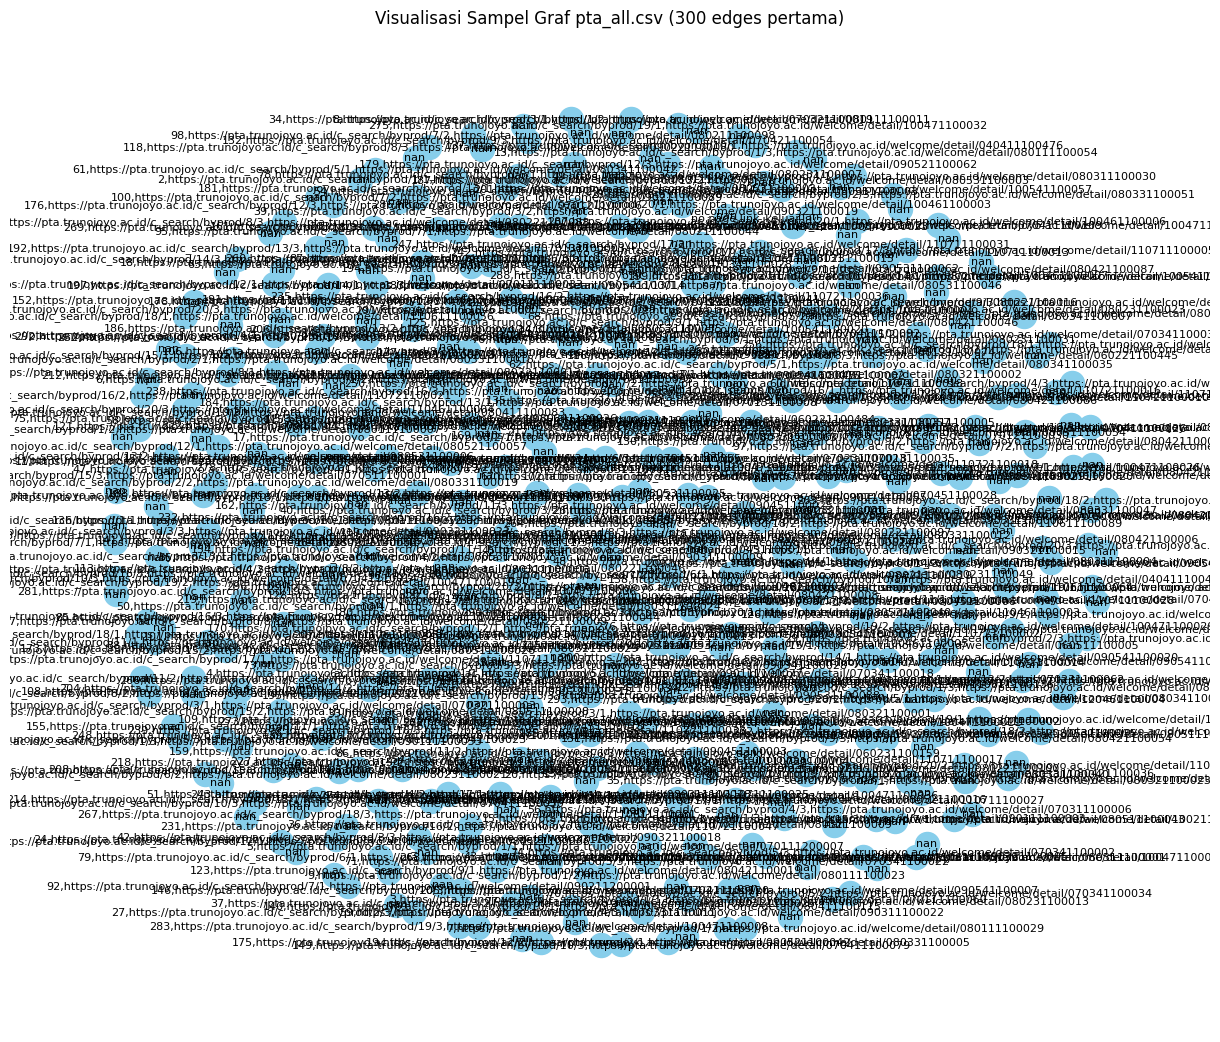

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import drive

# 1️⃣ Hubungkan Google Drive
drive.mount('/content/drive')

# 2️⃣ Tentukan path file di Drive
file_path = '/content/drive/MyDrive/Semester 7/PPW/pta_links.csv'

# 3️⃣ Baca dataset dengan format otomatis dan lewati baris rusak
df = pd.read_csv(
    file_path,
    comment="#",
    names=["FromNodeId", "ToNodeId"],
    delim_whitespace=True,  # otomatis deteksi tab/spasi
    on_bad_lines="skip"     # lewati baris yang salah format
)

# 4️⃣ Pastikan data berhasil dibaca
print("Jumlah baris:", len(df))
print("Kolom:", df.columns)
print("\n5 baris pertama:\n", df.head())

# 💡 Cegah error jika file kosong atau tidak punya kolom sesuai
if df.empty or not {"FromNodeId", "ToNodeId"}.issubset(df.columns):
    raise ValueError("❌ File tidak cocok. Cek pemisahnya (coba buka file dan lihat pakai koma, tab, atau spasi).")

# 5️⃣ Ambil sampel data kecil agar bisa divisualisasikan
sample_df = df.head(300)

# 6️⃣ Buat graf berarah
G = nx.DiGraph()
G.add_edges_from(zip(sample_df["FromNodeId"], sample_df["ToNodeId"]))

# 7️⃣ Visualisasikan graf
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=8,
    arrowsize=10,
    node_color="skyblue"
)
plt.title("Visualisasi Sampel Graf pta_all.csv (300 edges pertama)")
plt.show()


In [9]:
import pandas as pd
from google.colab import drive

# 1️⃣ Hubungkan ke Google Drive
drive.mount('/content/drive')

# 2️⃣ Path file
file_path = '/content/drive/MyDrive/Semester 7/PPW/pta_links.csv'

# 3️⃣ Baca dataset
df = pd.read_csv(file_path)

# 4️⃣ Hitung jumlah total data dan node unik
total_data = len(df)
total_node_unik = df['page'].nunique()

print("=== INFO DATASET ===")
print(f"Jumlah total data        : {total_data}")
print(f"Jumlah total node unik   : {total_node_unik}")
print(f"Jumlah data duplikat ID  : {total_data - total_node_unik}")

# 5️⃣ (Opsional) tampilkan ID yang duplikat
duplikat = df[df.duplicated(subset='no', keep=False)]
if not duplikat.empty:
    print("\n=== Data dengan ID duplikat ===")
    print(duplikat.sort_values('id').head(20))
else:
    print("\nTidak ada ID yang duplikat 🎉")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== INFO DATASET ===
Jumlah total data        : 481
Jumlah total node unik   : 98
Jumlah data duplikat ID  : 383

Tidak ada ID yang duplikat 🎉
